## Insurance Claim amount

1- Problem Statement

* The objective of this project is to predict the insurance claim amount using supervised machine learning.
The model uses structured claim details along with claim description text processed using NLP to estimate the final claim amount as an integer value.This helps insurance companies speed up claim processing and improve cost estimation accuracy.

2- Data Collection

* The dataset used in this project was created in a structured CSV format, inspired by real-world insurance claim data and common insurance risk factors.
It consists of 1200 sample records (rows) with multiple input features related to claim risk, policy details, and claim description text, along with one target column representing the insurance claim amount.

In [514]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [515]:
df=pd.read_csv("insurance_claims_amount.csv")

In [516]:
df.head()

,id,policy_type,accident_type,claim_severity_level,vehicle_category,area_type,vehicle_damage_score,accident_impact_score,repair_risk_index,injury_severity_prob,overall_claim_risk,agent_name,policy_number,claim_date,random_noise,claim_description,claim_amount
0,10001,A,Theft,Medium,Sedan,Urban,0.636,0.598,0.616,0.350,0.514,Neha,PN27401,2022-01-01,0.167,Moderate theft causing body and light damage,36017
1,10002,C,Collision,Medium,Sedan,Urban,0.861,1.000,0.994,0.184,0.644,Kunal,PN25428,2022-01-02,0.049,Moderate collision causing body and light damage,74032
2,10003,B,Collision,Medium,Sedan,Urban,0.717,0.025,0.425,0.590,0.550,Neha,PN74372,2022-01-03,0.396,Moderate collision causing body and light damage,38491
3,10004,B,Collision,Medium,Sedan,Urban,0.518,0.721,0.565,0.208,0.413,Suresh,PN21971,2022-01-04,0.854,Moderate collision causing body and light damage,42784
4,10005,A,Collision,Medium,SUV,Urban,0.651,0.521,0.553,0.391,0.508,Suresh,PN98018,2022-01-05,0.755,Moderate collision causing body and light damage,40923


In [517]:
df.shape

(1200, 17)

In [518]:
df.drop(["id","agent_name","policy_number","claim_date","random_noise"],axis=1,inplace=True)


In [519]:
df.head()

,policy_type,accident_type,claim_severity_level,vehicle_category,area_type,vehicle_damage_score,accident_impact_score,repair_risk_index,injury_severity_prob,overall_claim_risk,claim_description,claim_amount
0,A,Theft,Medium,Sedan,Urban,0.636,0.598,0.616,0.350,0.514,Moderate theft causing body and light damage,36017
1,C,Collision,Medium,Sedan,Urban,0.861,1.000,0.994,0.184,0.644,Moderate collision causing body and light damage,74032
2,B,Collision,Medium,Sedan,Urban,0.717,0.025,0.425,0.590,0.550,Moderate collision causing body and light damage,38491
3,B,Collision,Medium,Sedan,Urban,0.518,0.721,0.565,0.208,0.413,Moderate collision causing body and light damage,42784
4,A,Collision,Medium,SUV,Urban,0.651,0.521,0.553,0.391,0.508,Moderate collision causing body and light damage,40923


In [520]:
df.shape

(1200, 12)

## Datasheet information

* Policy type of the insured vehicle (A / B / C).
* Type of accident involved (Collision / Theft / Fire).
* Severity level of the insurance claim (Low / Medium / High).
* Category of the vehicle involved in the claim (Sedan / SUV / Truck).
* Area where the accident occurred (Urban / Rural).
* Vehicle damage score representing extent of physical damage.
* Accident impact score indicating intensity of the accident.
* Repair risk index estimating likelihood of costly repairs.
* Injury severity probability indicating chances of human injury.
* Overall claim risk score derived from multiple risk factors.
* Textual claim description provided by the policyholder.
* Insurance claim amount to be predicted (target variable).


## Data Checks to perform
- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of data set
- Check various categories present in the different categorical column


In [521]:
df.isnull().sum()

policy_type              0
accident_type            0
claim_severity_level     0
vehicle_category         0
area_type                0
vehicle_damage_score     0
accident_impact_score    0
repair_risk_index        0
injury_severity_prob     0
overall_claim_risk       0
claim_description        0
claim_amount             0
dtype: int64

In [522]:
df.duplicated().sum()

np.int64(0)

In [523]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   policy_type            1200 non-null   object 
 1   accident_type          1200 non-null   object 
 2   claim_severity_level   1200 non-null   object 
 3   vehicle_category       1200 non-null   object 
 4   area_type              1200 non-null   object 
 5   vehicle_damage_score   1200 non-null   float64
 6   accident_impact_score  1200 non-null   float64
 7   repair_risk_index      1200 non-null   float64
 8   injury_severity_prob   1200 non-null   float64
 9   overall_claim_risk     1200 non-null   float64
 10  claim_description      1200 non-null   object 
 11  claim_amount           1200 non-null   int64  
dtypes: float64(5), int64(1), object(6)
memory usage: 112.6+ KB


In [524]:
df.nunique()

policy_type                 3
accident_type               3
claim_severity_level        3
vehicle_category            3
area_type                   2
vehicle_damage_score      583
accident_impact_score     621
repair_risk_index         543
injury_severity_prob      597
overall_claim_risk        465
claim_description           9
claim_amount             1187
dtype: int64

In [525]:
df.describe()

,vehicle_damage_score,accident_impact_score,repair_risk_index,injury_severity_prob,overall_claim_risk,claim_amount
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,0.587850,0.539365,0.562351,0.387929,0.497679,43173.768333
std,0.194603,0.238875,0.166919,0.197449,0.122848,11515.880701
min,0.000000,0.000000,0.000000,0.016000,0.063000,10712.000000
25%,0.458750,0.374750,0.448500,0.229750,0.413750,34655.000000
50%,0.594500,0.543500,0.560000,0.367000,0.495000,42219.000000
75%,0.725000,0.709250,0.680000,0.533500,0.578250,50354.750000
max,1.000000,1.000000,1.000000,0.945000,0.917000,93008.000000


In [526]:
df.head()

,policy_type,accident_type,claim_severity_level,vehicle_category,area_type,vehicle_damage_score,accident_impact_score,repair_risk_index,injury_severity_prob,overall_claim_risk,claim_description,claim_amount
0,A,Theft,Medium,Sedan,Urban,0.636,0.598,0.616,0.350,0.514,Moderate theft causing body and light damage,36017
1,C,Collision,Medium,Sedan,Urban,0.861,1.000,0.994,0.184,0.644,Moderate collision causing body and light damage,74032
2,B,Collision,Medium,Sedan,Urban,0.717,0.025,0.425,0.590,0.550,Moderate collision causing body and light damage,38491
3,B,Collision,Medium,Sedan,Urban,0.518,0.721,0.565,0.208,0.413,Moderate collision causing body and light damage,42784
4,A,Collision,Medium,SUV,Urban,0.651,0.521,0.553,0.391,0.508,Moderate collision causing body and light damage,40923


In [527]:
print("Categories in 'policy_type' variable:     ",end=" " )
print(df['policy_type'].unique())

print("Categories in 'accident_type' variable:  ",end=" ")
print(df['accident_type'].unique())

print("Categories in'claim_severity_level' variable:",end=" " )
print(df['claim_severity_level'].unique())

print("Categories in 'vehicle_category' variable:     ",end=" " )
print(df['vehicle_category'].unique())

print("Categories in 'area_type' variable:     ",end=" " )
print(df['area_type'].unique())

print("Categories in 'claim_description variale:    ",end=" ")
print(df['claim_description'].unique())

Categories in 'policy_type' variable:      ['A' 'C' 'B']
Categories in 'accident_type' variable:   ['Theft' 'Collision' 'Fire']
Categories in'claim_severity_level' variable: ['Medium' 'Low' 'High']
Categories in 'vehicle_category' variable:      ['Sedan' 'SUV' 'Truck']
Categories in 'area_type' variable:      ['Urban' 'Rural']
Categories in 'claim_description variale:     ['Moderate theft causing body and light damage'
 'Moderate collision causing body and light damage'
 'Minor theft with small damage'
 'Moderate fire causing body and light damage'
 'Minor collision with small damage' 'Minor fire with small damage'
 'Severe collision with major damage and possible injuries'
 'Severe theft with major damage and possible injuries'
 'Severe fire with major damage and possible injuries']


In [528]:
df.shape

(1200, 12)

In [529]:
numeric_features=[feature for feature in df.columns if df[feature].dtype!='object']
categorical_features=[feature for feature in df.columns if df[feature].dtype=='object']


print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('We have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 6 numerical features : ['vehicle_damage_score', 'accident_impact_score', 'repair_risk_index', 'injury_severity_prob', 'overall_claim_risk', 'claim_amount']
We have 6 categorical features : ['policy_type', 'accident_type', 'claim_severity_level', 'vehicle_category', 'area_type', 'claim_description']


In [530]:
df.head()

,policy_type,accident_type,claim_severity_level,vehicle_category,area_type,vehicle_damage_score,accident_impact_score,repair_risk_index,injury_severity_prob,overall_claim_risk,claim_description,claim_amount
0,A,Theft,Medium,Sedan,Urban,0.636,0.598,0.616,0.350,0.514,Moderate theft causing body and light damage,36017
1,C,Collision,Medium,Sedan,Urban,0.861,1.000,0.994,0.184,0.644,Moderate collision causing body and light damage,74032
2,B,Collision,Medium,Sedan,Urban,0.717,0.025,0.425,0.590,0.550,Moderate collision causing body and light damage,38491
3,B,Collision,Medium,Sedan,Urban,0.518,0.721,0.565,0.208,0.413,Moderate collision causing body and light damage,42784
4,A,Collision,Medium,SUV,Urban,0.651,0.521,0.553,0.391,0.508,Moderate collision causing body and light damage,40923


In [531]:
Vehicles_with_Apolicy=df[df['policy_type']=='A']['policy_type'].count()
print(f'Number of Vehicles with A type policy: {Vehicles_with_Apolicy}')
Vehicles_with_Bpolicy=df[df['policy_type']=='B']['policy_type'].count()
print(f'Number of Vehicles with B type policy: {Vehicles_with_Bpolicy}')
Vehicles_with_Cpolicy=df[df['policy_type']=='C']['policy_type'].count()
print(f'Number of Vehicles with C type policy: {Vehicles_with_Cpolicy}')


Number of Vehicles with A type policy: 493
Number of Vehicles with B type policy: 399
Number of Vehicles with C type policy: 308


In [532]:
Accident_with_collision=df[df['accident_type']=='Collision']['policy_type'].count()
print(f'Number of accident with collision : {Accident_with_collision}')
Accident_with_Theft=df[df['accident_type']=='Theft']['policy_type'].count()
print(f'Number of accident with Theft : {Accident_with_Theft}')
Accident_with_fire=df[df['accident_type']=='Fire']['policy_type'].count()
print(f'Number of accident with Fire : {Accident_with_fire}')

Number of accident with collision : 706
Number of accident with Theft : 324
Number of accident with Fire : 170


In [533]:
Sedan_vehicles=df[df['vehicle_category']=='Sedan']['policy_type'].count()
print(f'Number of Sedan Vehicles : {Sedan_vehicles}')
SUV_vehicles=df[df['vehicle_category']=='SUV']['policy_type'].count()
print(f'Number of SUV vehicles : {SUV_vehicles}')
Truck_vehicles=df[df['vehicle_category']=='Truck']['policy_type'].count()
print(f'Number of Truck vehicles : {Truck_vehicles}')

Number of Sedan Vehicles : 543
Number of SUV vehicles : 420
Number of Truck vehicles : 237


In [534]:
Urban_claims=df[df['area_type']=='Urban']['policy_type'].count()
print(f'Number of claims in urban area : {Urban_claims}')
Rural_claims=df[df['area_type']=='Rural']['policy_type'].count()
print(f'Number of claims in rural area: {Rural_claims}')

Number of claims in urban area : 868
Number of claims in rural area: 332


Distribution of insurance claim amount

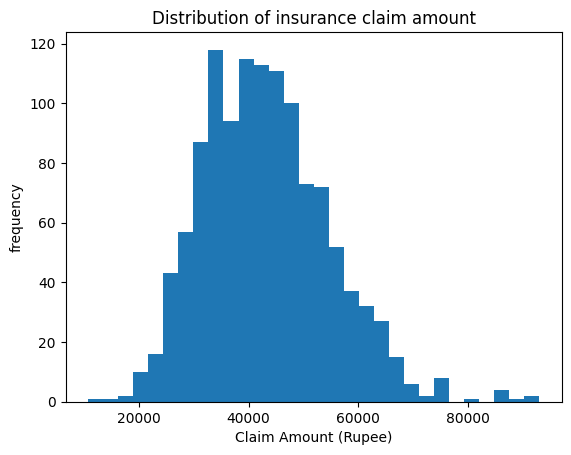

In [535]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df['claim_amount'], bins=30)
plt.xlabel('Claim Amount (Rupee)')
plt.ylabel('frequency')
plt.title('Distribution of insurance claim amount')
plt.show()


Claims in Urban and Rural Areas

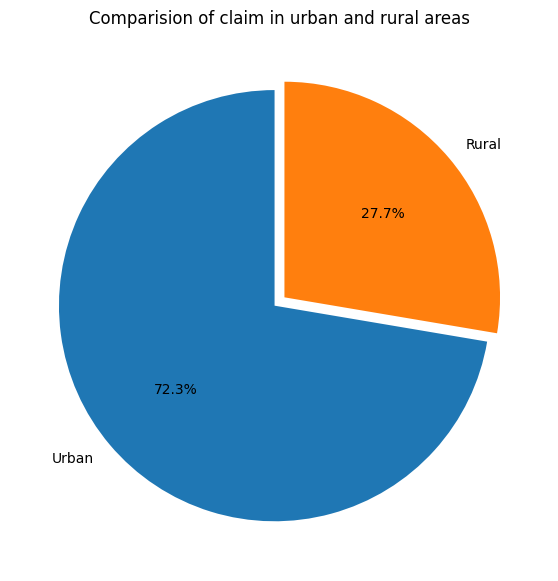

In [536]:
area_counts = df['area_type'].value_counts()
plt.figure(figsize=(7,7))
plt.pie(
    area_counts,
    labels=area_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    explode=(0.03, 0.03, )
)
plt.title("Comparision of claim in urban and rural areas")
plt.show()


Distribution of accident types

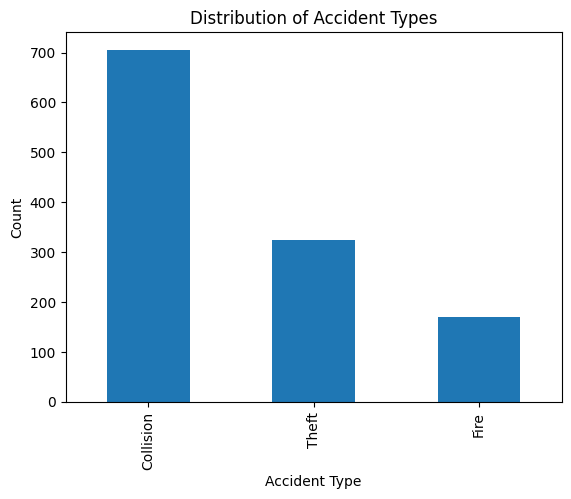

In [537]:
plt.figure()
df['accident_type'].value_counts().plot(kind='bar')
plt.xlabel('Accident Type')
plt.ylabel('Count')
plt.title('Distribution of Accident Types')
plt.show()


Relationship Between Vehicle Damage and Claim Amount

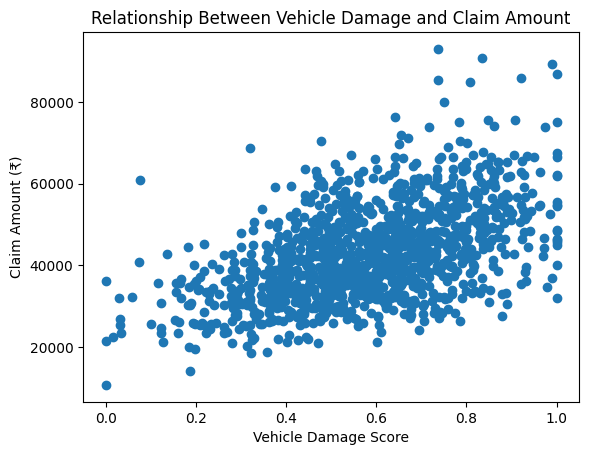

In [538]:
plt.figure()
plt.scatter(df['vehicle_damage_score'], df['claim_amount'])
plt.xlabel('Vehicle Damage Score')
plt.ylabel('Claim Amount (₹)')
plt.title('Relationship Between Vehicle Damage and Claim Amount')
plt.show()


In [539]:
df.head()

,policy_type,accident_type,claim_severity_level,vehicle_category,area_type,vehicle_damage_score,accident_impact_score,repair_risk_index,injury_severity_prob,overall_claim_risk,claim_description,claim_amount
0,A,Theft,Medium,Sedan,Urban,0.636,0.598,0.616,0.350,0.514,Moderate theft causing body and light damage,36017
1,C,Collision,Medium,Sedan,Urban,0.861,1.000,0.994,0.184,0.644,Moderate collision causing body and light damage,74032
2,B,Collision,Medium,Sedan,Urban,0.717,0.025,0.425,0.590,0.550,Moderate collision causing body and light damage,38491
3,B,Collision,Medium,Sedan,Urban,0.518,0.721,0.565,0.208,0.413,Moderate collision causing body and light damage,42784
4,A,Collision,Medium,SUV,Urban,0.651,0.521,0.553,0.391,0.508,Moderate collision causing body and light damage,40923


Policy type vs claim severity level

<Figure size 800x600 with 0 Axes>

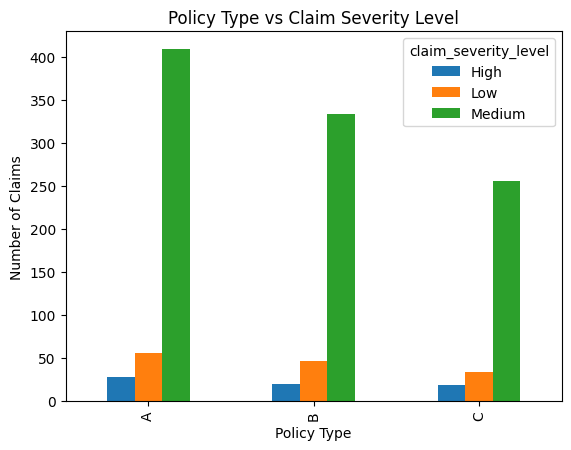

In [540]:
plt.figure(figsize=(8,6))
pd.crosstab(df['policy_type'], df['claim_severity_level']).plot(kind='bar')
plt.xlabel('Policy Type')
plt.ylabel('Number of Claims')
plt.title('Policy Type vs Claim Severity Level')
plt.show()


Claim amount Distribution by area type

<Figure size 640x480 with 0 Axes>

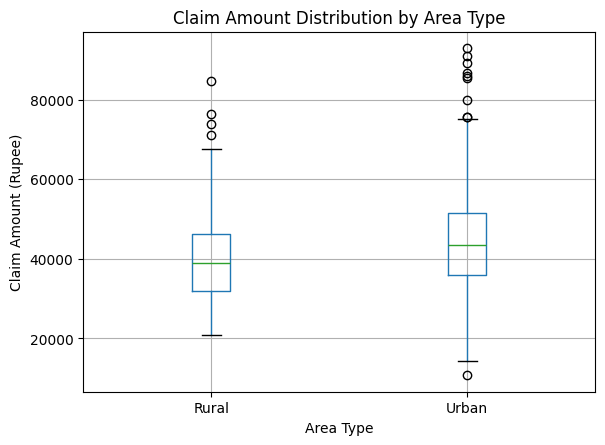

In [541]:
plt.figure()
df.boxplot(column='claim_amount', by='area_type')
plt.xlabel('Area Type')
plt.ylabel('Claim Amount (Rupee)')
plt.title('Claim Amount Distribution by Area Type')
plt.suptitle('')
plt.show()


In [542]:
df.head()

,policy_type,accident_type,claim_severity_level,vehicle_category,area_type,vehicle_damage_score,accident_impact_score,repair_risk_index,injury_severity_prob,overall_claim_risk,claim_description,claim_amount
0,A,Theft,Medium,Sedan,Urban,0.636,0.598,0.616,0.350,0.514,Moderate theft causing body and light damage,36017
1,C,Collision,Medium,Sedan,Urban,0.861,1.000,0.994,0.184,0.644,Moderate collision causing body and light damage,74032
2,B,Collision,Medium,Sedan,Urban,0.717,0.025,0.425,0.590,0.550,Moderate collision causing body and light damage,38491
3,B,Collision,Medium,Sedan,Urban,0.518,0.721,0.565,0.208,0.413,Moderate collision causing body and light damage,42784
4,A,Collision,Medium,SUV,Urban,0.651,0.521,0.553,0.391,0.508,Moderate collision causing body and light damage,40923


# Text Preprocessing and Feature Extraction using TF-IDF

Claim description contains unstructured textual information useful for understanding claim severity

In [543]:
import re
import nltk
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/harshit/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [544]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
wordlemmatize=WordNetLemmatizer()
corpus=[]
for i in range(0,len(df)):
    review=re.sub('[^a-zA-Z]',' ',df['claim_description'][i])
    review=review.lower()
    review=review.split()
    review=[wordlemmatize.lemmatize(word) for word in review if word not in stopwords.words('english')]
    review=' '.join(review)
    corpus.append(review)
corpus

['moderate theft causing body light damage',
 'moderate collision causing body light damage',
 'moderate collision causing body light damage',
 'moderate collision causing body light damage',
 'moderate collision causing body light damage',
 'moderate theft causing body light damage',
 'minor theft small damage',
 'moderate collision causing body light damage',
 'moderate collision causing body light damage',
 'moderate fire causing body light damage',
 'minor collision small damage',
 'moderate collision causing body light damage',
 'moderate collision causing body light damage',
 'minor theft small damage',
 'minor theft small damage',
 'moderate collision causing body light damage',
 'moderate collision causing body light damage',
 'moderate theft causing body light damage',
 'moderate theft causing body light damage',
 'moderate collision causing body light damage',
 'moderate fire causing body light damage',
 'moderate collision causing body light damage',
 'moderate collision cau

In [545]:
df['claim_description']=corpus

Train-Test Split

In [546]:
from socketserver import ThreadingUnixDatagramServer
from sklearn.model_selection import train_test_split
X=df.drop('claim_amount',axis=1)
y=df['claim_amount']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [547]:
num_features = X.select_dtypes(exclude="object").columns
cat_features = X.drop('claim_description',axis=1).select_dtypes(include="object").columns
text_feature='claim_description'

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
         ("StandardScaler", numeric_transformer, num_features),   
         ('txt', TfidfVectorizer(max_features=100, ngram_range=(1,2)), text_feature)     
    ]
)

In [548]:
X_train=preprocessor.fit_transform(X_train)
pd.DataFrame(X_train)

,0,1,2,3,4,5,6,7,8,9,...,48,49,50,51,52,53,54,55,56,57
0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,...,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.435312,0.463786,0.0,0.0
1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0
2,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0
3,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.000000,0.0,0.000000,0.0,0.409942,0.409942,0.000000,0.000000,0.0,0.0
4,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
955,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.288053,0.0,0.427794,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0
956,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0
957,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0
958,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0


In [549]:
X_train.shape

(960, 58)

In [550]:
X_test=preprocessor.transform(X_test)
X_test.shape

(240, 58)

# Model Training And Model Selection

In [551]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


Function to Evaluate the model

In [552]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square


In [553]:
best_model_name = None
best_model = None
best_test_r2 = -float("inf")
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "Adaboost Regressor":AdaBoostRegressor(),
    "Graident BoostRegressor":GradientBoostingRegressor(),
    
   
}
model_list = []
r2_list =[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model_name = list(models.keys())[i]
    model.fit(X_train, y_train) 

    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    if model_test_r2 > best_test_r2:
        best_test_r2 = model_test_r2
        best_model_name = model_name
        best_model = model

    
    print(model_name)
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')

print("BEST MODEL SELECTED")
print("Model Name:", best_model_name)
print("Best Test R2 Score:", round(best_test_r2, 4))

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 1880.6756
- Mean Absolute Error: 1428.5581
- R2 Score: 0.9730
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 1861.9614
- Mean Absolute Error: 1397.1164
- R2 Score: 0.9750


Lasso
Model performance for Training set
- Root Mean Squared Error: 1881.4837
- Mean Absolute Error: 1428.0424
- R2 Score: 0.9730
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 1861.0352
- Mean Absolute Error: 1394.1304
- R2 Score: 0.9750


Ridge
Model performance for Training set
- Root Mean Squared Error: 1886.2054
- Mean Absolute Error: 1431.2820
- R2 Score: 0.9728
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 1860.5899
- Mean Absolute Error: 1388.2928
- R2 Score: 0.9750


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 2935.9779
- Mean Absolute Error: 2115.7098


In [554]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
2,Ridge,0.975007
1,Lasso,0.974995
0,Linear Regression,0.974970
7,Graident BoostRegressor,0.970232
5,Random Forest Regressor,0.939745
3,K-Neighbors Regressor,0.889760
6,Adaboost Regressor,0.866920
4,Decision Tree,0.842847


# Hyperparameter tuning on the best model selected

few parameter for hyperparameter tuning

In [555]:
ridge_params = {
    "alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10, 50, 100, 500],
    "fit_intercept": [True, False],
    "solver": ["auto", "svd", "cholesky", "lsqr", "sag"]
}
lasso_params = {
    "alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10, 50],
    "max_iter": [1000, 2000, 5000]
}
gradient_params={"loss": ['squared_error','huber','absolute_error'],
             "criterion": ['friedman_mse','squared_error','mse'],
             "min_samples_split": [2, 8, 15, 20],
             "n_estimators": [100, 200, 500],
              "max_depth": [5, 8, 15, None, 10],
            }




In [556]:
randomcv_models = [
                   ("RIDGE", Ridge(), ridge_params),
                   ("LASSO",Lasso(),lasso_params),
                   ("GRDB",GradientBoostingRegressor(),gradient_params)
]

In [557]:
from sklearn.model_selection import RandomizedSearchCV

model_param = {}
for name, model, params in randomcv_models:
    random = RandomizedSearchCV(estimator=model,
                                   param_distributions=params,
                                   n_iter=100,
                                   cv=3,
                                   verbose=2,
                                   n_jobs=-1)
    random.fit(X_train, y_train)
    model_param[name] = random.best_params_

for model_name in model_param:
    print(f"---------------- Best Params for {model_name} -------------------")
    print(model_param[model_name])

Fitting 3 folds for each of 90 candidates, totalling 270 fits
[CV] END ......alpha=0.0001, fit_intercept=True, solver=auto; total time=   0.0s
[CV] END .......alpha=0.0001, fit_intercept=True, solver=svd; total time=   0.0s
[CV] END .......alpha=0.0001, fit_intercept=True, solver=svd; total time=   0.0s
[CV] END ..alpha=0.0001, fit_intercept=True, solver=cholesky; total time=   0.0s
[CV] END ......alpha=0.0001, fit_intercept=True, solver=auto; total time=   0.0s
[CV] END ......alpha=0.0001, fit_intercept=True, solver=auto; total time=   0.0s
[CV] END ..alpha=0.0001, fit_intercept=True, solver=cholesky; total time=   0.0s
[CV] END ..alpha=0.0001, fit_intercept=True, solver=cholesky; total time=   0.0s
[CV] END ......alpha=0.0001, fit_intercept=True, solver=lsqr; total time=   0.0s
[CV] END ......alpha=0.0001, fit_intercept=True, solver=lsqr; total time=   0.0s
[CV] END ......alpha=0.0001, fit_intercept=True, solver=lsqr; total time=   0.0s
[CV] END .....alpha=0.0001, fit_intercept=False

In [558]:
best_model_name = None
best_model = None
best_test_r2 = -float("inf")

models = {
    "Ridge ": Ridge(solver='sag',fit_intercept=True,alpha=0.0001),
    "Lasso":Lasso(max_iter=1000,alpha=0.01),
    "Gradient Boosting Regressor":GradientBoostingRegressor(n_estimators=500,min_samples_split=20,max_depth=5,loss='huber',criterion='squared_error')
}

model_list = []
r2_list =[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model_name = list(models.keys())[i]
    model.fit(X_train, y_train) 

    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    if model_test_r2 > best_test_r2:
        best_test_r2 = model_test_r2
        best_model_name = model_name
        best_model = model

    
    print(model_name)
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')

print("BEST MODEL SELECTED")
print("Model Name:", best_model_name)
print("Best Test R2 Score:", round(best_test_r2, 4))

Ridge 
Model performance for Training set
- Root Mean Squared Error: 1881.0915
- Mean Absolute Error: 1427.6268
- R2 Score: 0.9730
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 1864.4293
- Mean Absolute Error: 1397.1063
- R2 Score: 0.9749


Lasso
Model performance for Training set
- Root Mean Squared Error: 1880.9807
- Mean Absolute Error: 1427.6628
- R2 Score: 0.9730
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 1864.0478
- Mean Absolute Error: 1397.1278
- R2 Score: 0.9749


Gradient Boosting Regressor
Model performance for Training set
- Root Mean Squared Error: 288.2407
- Mean Absolute Error: 169.0412
- R2 Score: 0.9994
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 1985.5946
- Mean Absolute Error: 1526.5219
- R2 Score: 0.9715


BEST MODEL SELECTED
Model Name: Lasso
Best Test R2 Score: 0.9749


In [559]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
1,Lasso,0.974914
0,Ridge,0.974904
2,Gradient Boosting Regressor,0.971536


# Lasso

In [560]:
Lasso(max_iter=1000,alpha=0.01)
las_model = Lasso(max_iter=1000,alpha=0.01)
las_model = las_model.fit(X_train, y_train)
y_pred = las_model.predict(X_test)
score = r2_score(y_test, y_pred)*100
print(" Accuracy of the model is %.4f" %score)

 Accuracy of the model is 97.4914


# y_pred and y_test Plot

Text(0, 0.5, 'Predicted')

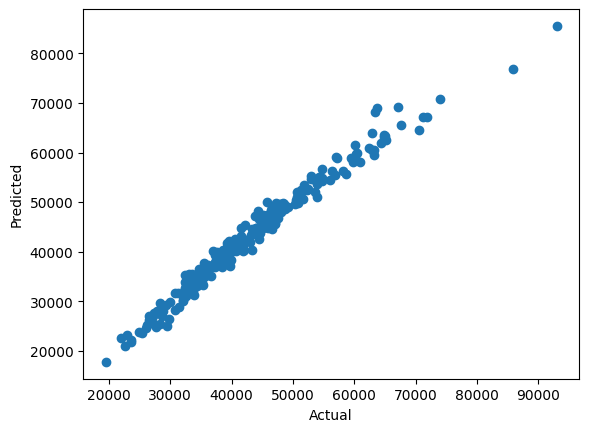

In [561]:
plt.scatter(y_test,y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')

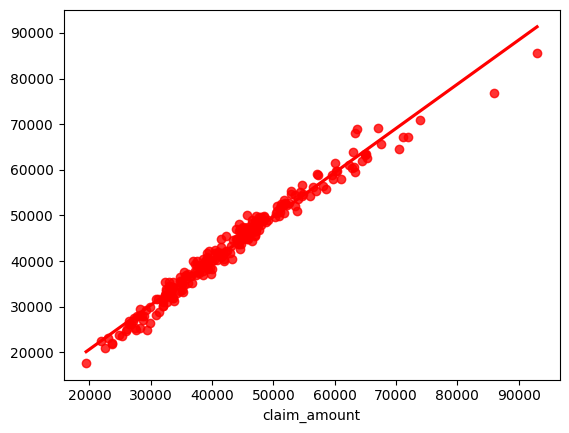

In [562]:
sns.regplot(x=y_test,y=y_pred,ci=None,color ='red');

In [563]:
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
1178,59522,58893.450622,628.549378
865,33123,34364.277124,-1241.277124
101,54275,55153.443954,-878.443954
439,60277,59719.429742,557.570258
58,33676,31974.337641,1701.662359
...,...,...,...
382,33076,32042.550328,1033.449672
867,40032,40028.897972,3.102028
542,45323,47230.637531,-1907.637531
1193,47008,45685.654447,1322.345553


In [564]:
import pickle
final_model = list(models.values())[1]


pickle.dump(
    {
        "model": final_model,
        "preprocessor": preprocessor,
        
    },
    open("regmodel.pkl", "wb")
)


pickle_model = pickle.load(open("regmodel.pkl", "rb"))


In [565]:
loaded_model = pickle_model["model"]
loaded_preprocessor = pickle_model["preprocessor"]


X_sample = X_test[:1]



prediction = loaded_model.predict(X_sample)

print(prediction)

[58893.4506219]
